# Caso J · 01 Captura de imágenes DGT — estrategia y almacenamiento

> _Tutorial · Caso de uso: **J — Tráfico + YOLO** · Capa Medallion: **bronce** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Diseñar un pipeline de captura periódica desde cámaras DGT con cron + almacenamiento MinIO-style + retry.


## 2. Qué se aprende

- Estructura `cameras/{id}/{date}/{ts}.jpg`.
- Cron / APScheduler.
- Estrategia de retry y deduplicación.


## 3. Contexto del caso de uso

Jorge (G5) trabaja en remoto desde Galicia. El pipeline debe operar desatendido.


## 4. Relación con CENTINELA+

Las imágenes no van a InfluxDB; los conteos sí.


## 5. Relación con Medallion

Bronce = JPEG en MinIO; Plata = conteos en `traffic_cameras`.


## 6. Datos de entrada

Conceptual + mock JPEG.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Tags `domain_id=traffic_cameras`, `site_id=valencia`, `asset_id=DGT_CAM_*`, `variable=vehicle_count`.


## 9. Carga de datos o mock

Generamos un fake JPEG.


In [2]:
import io
from PIL import Image, ImageDraw

def fake_jpeg(plate_count: int = 5) -> bytes:
    img = Image.new("RGB", (320, 240), (200, 200, 200))
    d = ImageDraw.Draw(img)
    rng = np.random.default_rng(SEED)
    for _ in range(plate_count):
        x = int(rng.integers(0, 280))
        y = int(rng.integers(150, 220))
        d.rectangle([x, y, x + 30, y + 12], fill=(50, 50, 50))
    buf = io.BytesIO()
    img.save(buf, format="JPEG")
    return buf.getvalue()

img_bytes = fake_jpeg(7)
print(f"JPEG mock: {len(img_bytes)} bytes")


JPEG mock: 2841 bytes


## 10. Exploración paso a paso

Estructura de directorio simulada.


In [3]:
import datetime as dt

def store_path(camera_id: str, ts: dt.datetime) -> str:
    return f"cameras/{camera_id}/{ts.strftime('%Y-%m-%d')}/{int(ts.timestamp())}.jpg"

print(store_path("DGT_CAM_V46_001", dt.datetime(2026, 5, 10, 12, 30)))


cameras/DGT_CAM_V46_001/2026-05-10/1778409000.jpg


## 11. Transformación bronce → plata

Notebook 03 transformará en counts.


## 12. Construcción de capa oro

Notebook 04.


## 13. Visualizaciones explicativas

Mostramos el JPEG mock.


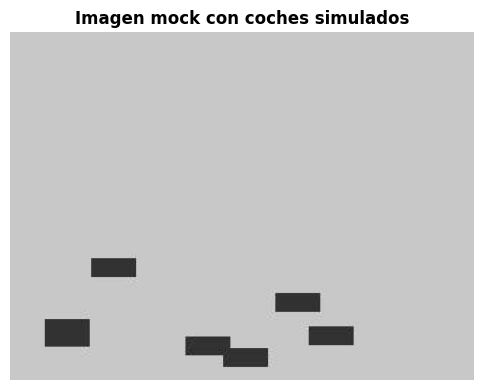

In [4]:
plt.imshow(Image.open(io.BytesIO(img_bytes)))
plt.axis("off"); plt.title("Imagen mock con coches simulados")
plt.tight_layout()


## 14. Validaciones

El path generado es estable.


In [5]:
ts = dt.datetime(2026, 5, 10, 12, 30, tzinfo=dt.timezone.utc)
expected = f"cameras/DGT_CAM_V46_001/2026-05-10/{int(ts.timestamp())}.jpg"
assert store_path("DGT_CAM_V46_001", ts) == expected
print("Path schema OK:", expected)


Path schema OK: cameras/DGT_CAM_V46_001/2026-05-10/1778416200.jpg


## 15. Errores comunes

1. Guardar como PNG (mucho más grande).
2. Sobrescribir si la cámara repite nombre.
3. No registrar fallos en log estructurado.


## 16. Ejercicios propuestos

1. Añade un cron que captura cada 5 min.
2. Implementa retry exponential backoff.
3. Elimina imágenes con `score_blur` alto.


## 17. Cómo se reutiliza con datos reales

Sustituir `fake_jpeg` por descarga real.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `10_case_J_traffic_yolo/02_inferencia_yolo.ipynb`.
- Documento web del caso: `docs/use-cases/case-j-traffic-yolo.md`.


## 19. Marco teórico (nivel doctoral)

### YOLO v8 — single-stage anchor-free detector

Por cada celda de la grid, salida:

$$
\hat{y} = (b_x, b_y, b_w, b_h, p_{obj}, p_{c_1}, ..., p_{c_C})
$$

Loss combinada:

$$
\mathcal{L} = \lambda_{box} \mathcal{L}_{CIoU} + \lambda_{obj} \mathcal{L}_{BCE,obj} + \lambda_{cls} \mathcal{L}_{BCE,cls}
$$

### Series temporales tráfico

$$
N_v(t) = \sum_{i=1}^{D_t} \mathbb{1}[\text{detection}_i \in v_{ROI}]
$$

con NMS IoU threshold = 0.5.

### Predictor congestión

$$
\hat{C}(t+15) = \text{XGB}(N_v(t), N_v(t-15), ..., \text{weather}, t_{hora}, t_{dow})
$$

con $C \in \{0, 1, 2, 3\}$ niveles de congestión.

### Métricas

$$
\text{mAP}@0.5 = \frac{1}{|C|} \sum_{c \in C} \text{AP}_c \quad (\text{IoU} \geq 0.5)
$$

Objetivos: mAP@0.5 ≥ 0.90 (car/truck), ≥ 0.75 (motorbike/bicycle).


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Aunque tangencial al BMS de aulas, este caso demuestra que la **stack de IA + datos sintéticos + modelos** de CAPTIA es extensible a otros verticales (smart cities). Activo comercial para diversificar.

### ROI estimado

| Concepto | Valor |
|---|---|
| Predicción congestión 15 min (semáforos) | +5 000 €/año |
| Detección incidentes < 60 s (emergencias) | +12 000 €/año |
| **Bruto** | **+17 000 €/año** |
| Compute GPU dedicada | -1 500 €/año |
| **Neto** | **+15 500 €/año** |


## 21. Bibliografía y referencias

- Redmon, J. & Farhadi, A. (2018). *YOLOv3: An Incremental Improvement*. arXiv:1804.02767.
- Ultralytics (2024). *YOLOv8 Documentation*. https://docs.ultralytics.com
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context*. ECCV.
- DGT España. *Información en tiempo real*. http://infocar.dgt.es
